In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

def highlight_max(row):
    is_max = row == row.max()
    return ['font-weight: bold' if v else '' for v in is_max]

def drop_nan_group(group):
    if group.isnull().any():
        return None  # Returning None will drop the group
    else:
        return group

def compte_les_points(df):
    results = {}
    total = 0
    for idx, row in df.reset_index()['perf'].iterrows():
        is_max = row == row.max()
        for key in is_max.reset_index()['package'].values:
            if key not in results:
                results[key] = 0
                
            results[key] += int(is_max[key])
        total += 1
            
    for key in results:
        print(f"{key} : {results[key]} / {total}")
        
def replace_by_dummy(df):
    # All unique combinations for 'fold', 'max_duration', 'dataset'
    all_combinations = df[['fold', 'max_duration', 'dataset']].drop_duplicates()

    # Dummy package performance values
    dummy_values = df[df['package'] == 'dummy']

    # Ensuring we're considering all combinations with dummy values
    full_combinations = pd.merge(all_combinations, dummy_values, on=['fold', 'max_duration', 'dataset'], how='left')

    # Identifying missing package rows except dummy
    needed_packages = df['package'].unique()
    missing_rows = []

    for package in needed_packages:
        current_df = df[df['package'] == package]
        merged_df = pd.merge(full_combinations, current_df, on=['fold', 'max_duration', 'dataset', 'package'], how='left', suffixes=('_dummy', ''))
        missing_data = merged_df[merged_df['perf'].isnull()]
        missing_data['package'] = package
        missing_data['perf'] = missing_data['perf_dummy']
        missing_rows.append(missing_data[['package', 'fold', 'max_duration', 'dataset', 'perf']])

    # Concatenating the missing rows to the original DataFrame
    if missing_rows:
        df = pd.concat([df] + missing_rows, ignore_index=True)
        
    return df

# Clean

In [6]:

bench = pd.read_csv("/Users/rudy/Documents/CHU/iias/baiddy_group/automl/src/perf_logger/tests_data/bench_v2.log")
print(bench.shape)
bench['perf'] = bench.apply(lambda row: row['balanced_accuracy'] if pd.notnull(row['balanced_accuracy']) else row['r2_score'], axis=1)
bench = bench[(bench['max_duration'] - bench['compute_time']) >= -30] # remove line with too long computing time
bench = bench[~bench['package'].isin(['automed_old', 'automed_old2'])] # remove line with too long computing time
count_fold = bench.groupby(['package', 'max_duration', 'dataset']).count().reset_index()[['package', 'max_duration', 'dataset', 'fold']]

joined = bench.merge(count_fold, on=['package', 'max_duration', 'dataset'], suffixes=('', '_count'))
bench = joined[joined['fold_count'] == 5]

# Compute perf
bench['perf'] = bench.apply(lambda row: row['balanced_accuracy'] if pd.notnull(row['balanced_accuracy']) else row['r2_score'], axis=1)

# Replace NAN by DUMMY
bench = replace_by_dummy(bench)

bench.head()

(2840, 21)


/var/folders/t5/v74j6bss1sn_0r4d6y9g65vc0000gn/T/ipykernel_67020/2662056616.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bench['perf'] = bench.apply(lambda row: row['balanced_accuracy'] if pd.notnull(row['balanced_accuracy']) else row['r2_score'], axis=1)
/var/folders/t5/v74j6bss1sn_0r4d6y9g65vc0000gn/T/ipykernel_67020/1825396760.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_data['package'] = package
/var/folders/t5/v74j6bss1sn_0r4d6y9g65vc0000gn/T/ipykernel_67020/1825396760.py:51: Se

,bench_date,package,fold,max_duration,compute_time,dataset,model_name,accuracy,balanced_accuracy,classification_error,f1_score,precision,recall,specificity_multiclass,specificity,mean_absolute_error,mean_squared_error,mean_squared_log_error,median_absolute_error,r2_score,ROC AUC,perf,fold_count
0,1.712172e+09,naive_autoML,0,30,22.0,HepatitisCdata.csv,"Pipeline(steps=[('impute_and_binarize',\n ...",0.934959,0.544798,0.455202,0.931488,0.932697,0.934959,0.983740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.544798,5.0
1,1.712172e+09,naive_autoML,1,30,20.0,HepatitisCdata.csv,"Pipeline(steps=[('impute_and_binarize',\n ...",0.943089,0.556667,0.443333,0.928480,0.937549,0.943089,0.985772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.556667,5.0
2,1.712172e+09,naive_autoML,2,30,20.0,HepatitisCdata.csv,"Pipeline(steps=[('impute_and_binarize',\n ...",0.926829,0.456667,0.543333,0.912581,0.915192,0.926829,0.981707,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.456667,5.0
3,1.712172e+09,naive_autoML,3,30,21.0,HepatitisCdata.csv,"Pipeline(steps=[('impute_and_binarize',\n ...",0.894309,0.350000,0.650000,0.870738,0.851493,0.894309,0.973577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.350000,5.0
4,1.712172e+09,naive_autoML,4,30,21.0,HepatitisCdata.csv,"Pipeline(steps=[('impute_and_binarize',\n ...",0.894309,0.333333,0.666667,0.855490,0.820017,0.894309,0.973577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.333333,5.0


# Analyse

# With folds

In [7]:
merged_df = bench[['package', 'max_duration', 'dataset', 'perf', 'fold']]
grouped = merged_df.groupby(['package', 'max_duration', 'dataset', 'fold']).mean(numeric_only=True).reset_index()[['package', 'perf', 'max_duration', 'dataset', 'fold']].dropna()

# grouped
pivot_df = grouped.pivot(index=['dataset', 'max_duration', 'fold'], columns='package')#.dropna()
pivot_df.style.apply(highlight_max, axis=1)

None

# Mean of folds

In [8]:
merged_df = bench[['package', 'max_duration', 'dataset', 'perf', 'compute_time']]
grouped = merged_df.groupby(['package', 'max_duration', 'dataset']).mean(numeric_only=True).reset_index()[['package', 'perf', 'max_duration', 'dataset']].dropna()

# grouped
pivot_df = grouped.pivot(index=['dataset', 'max_duration'], columns='package')#.dropna()
pivot_df.style.apply(highlight_max, axis=1)

In [9]:
# def count(row):
#     is_max = row == row.max()
#     return ['font-weight: bold' if v else '' for v in is_max]

# pivot_df = grouped.pivot(index=['dataset_name', 'duration'], columns='package')

# pivot_df.style.apply(highlight_max, axis=1)

compte_les_points(pivot_df)

FEDOT : 36 / 129
auto_sklearn : 61 / 129
automed : 53 / 129
dummy : 33 / 129
flaml : 43 / 129
naive_autoML : 63 / 129


In [10]:
# Auto-Sklearn : 14 / 75
# AutoMed : 29 / 75
# NaiveAutoML : 38 / 75

In [11]:
# PAR DATASET sans prendre ne compte le temps
without_duration = grouped.drop(columns=['max_duration'])
without_duration

pivot_df = without_duration.groupby(['package', 'dataset']).max(numeric_only=True).reset_index().pivot(index=['dataset'], columns='package')#.dropna()
pivot_df.style.apply(highlight_max, axis=1)

# Attention Naive_AutoML à probablement plus de temps ci-dessus

In [12]:
compte_les_points(pivot_df)

FEDOT : 3 / 27
auto_sklearn : 11 / 27
automed : 8 / 27
dummy : 2 / 27
flaml : 6 / 27
naive_autoML : 8 / 27


In [13]:


def line_plot(df, filter_tuple, hue="dataset",zero_line=False, y_lim=None):
    plt.figure()
    plot = sns.lineplot(data=df[df[filter_tuple[0]] == filter_tuple[1]], x="max_duration", y="perf", hue=hue) 
    sns.move_legend(plot, "upper left", bbox_to_anchor=(1, 1))
    plt.title(str(filter_tuple))
    if zero_line:
        plt.axhline(y=0.0, color='r', linestyle='--')
        
    if y_lim:
        plt.ylim(*y_lim)
    plt.show()
    
def bar_plot(df, dataset, show_fold=False):
    if not show_fold:
        df = df.groupby(['package', 'max_duration', 'dataset']).mean(numeric_only=True).reset_index()
    
    package_order = sorted(df['package'].unique())
    plot = sns.barplot(data=df[df['dataset'] == dataset], x='max_duration', y='perf', hue='package', hue_order=package_order)
    sns.move_legend(plot, "upper left", bbox_to_anchor=(1, 1))
    plt.title(str(dataset))
    plt.show()


merged_df = bench[['package', 'max_duration', 'dataset', 'perf']]
merged_df = merged_df.dropna() # Avoid penalize a package if no value


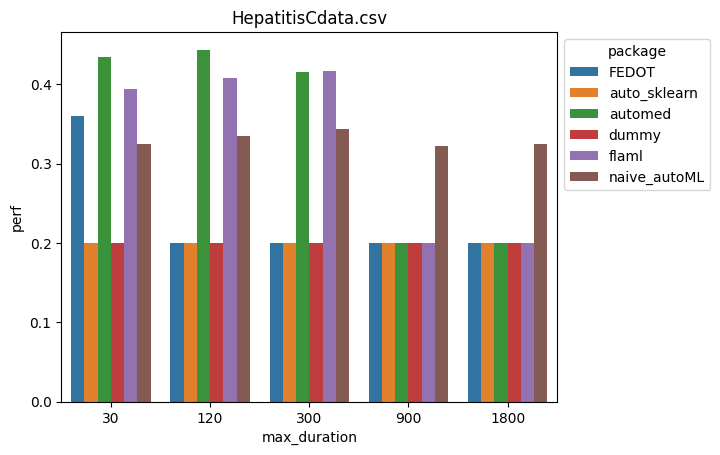

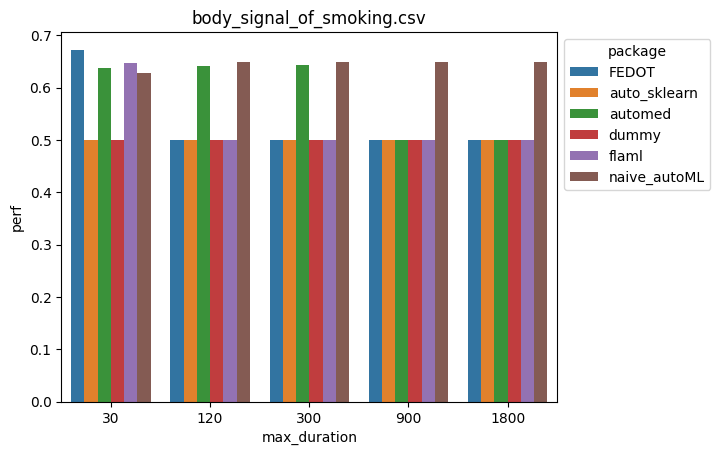

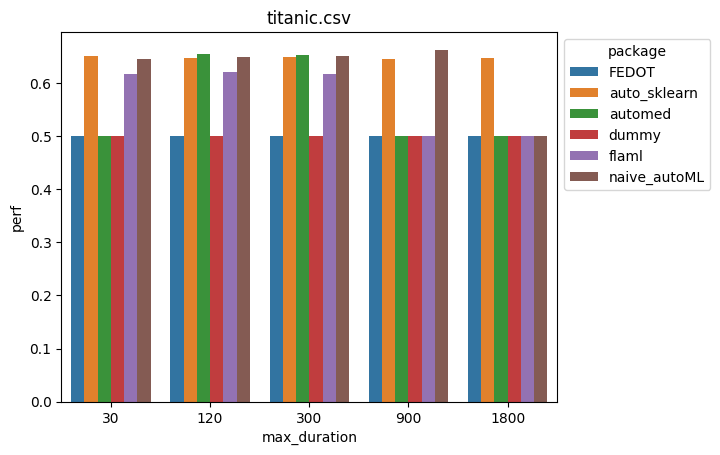

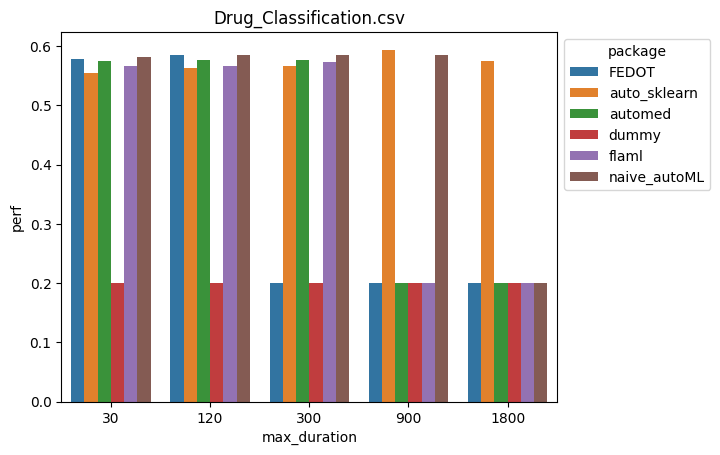

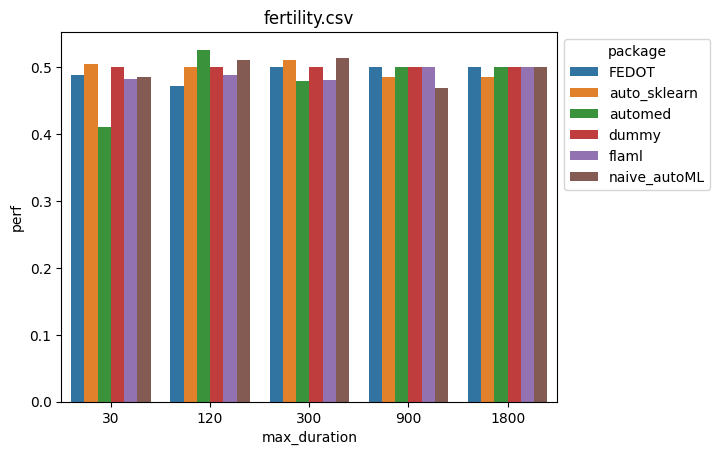

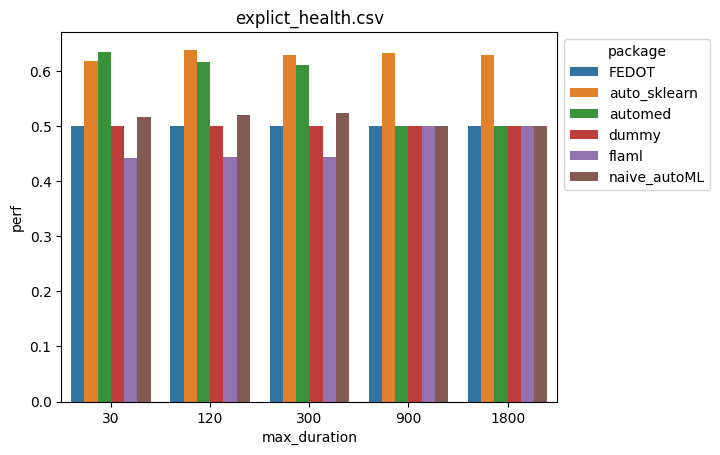

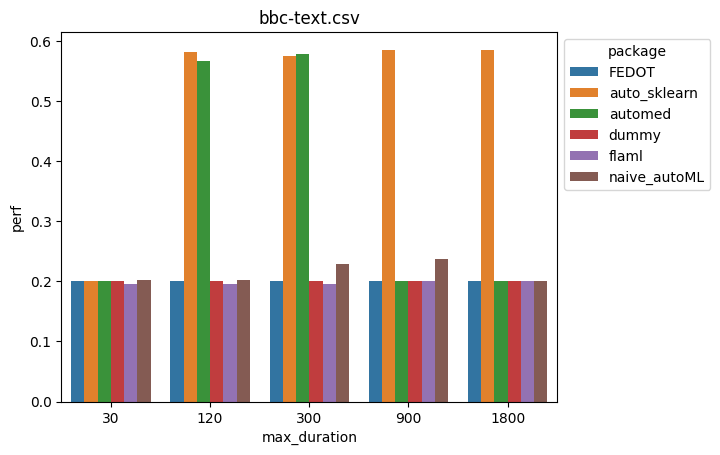

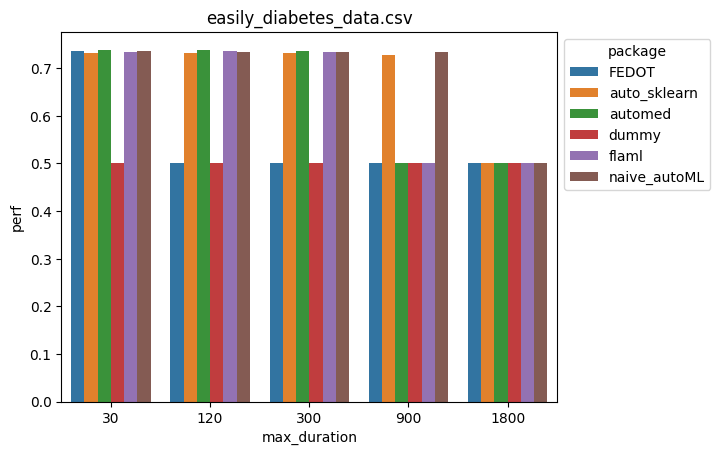

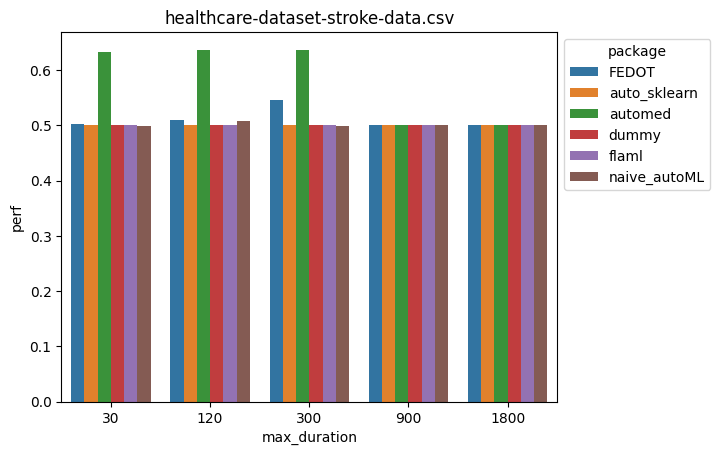

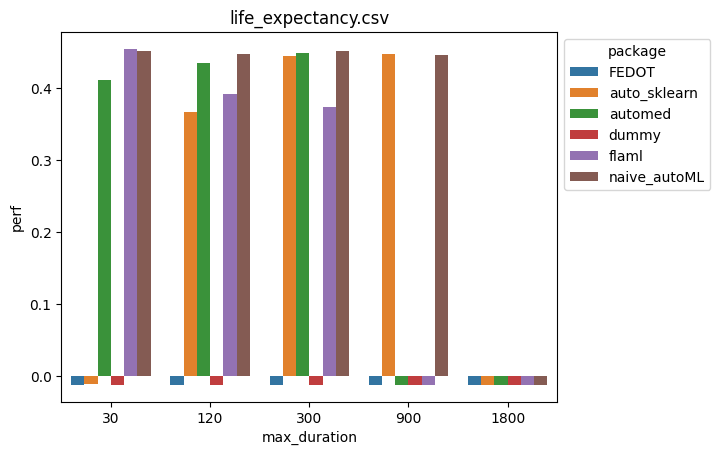

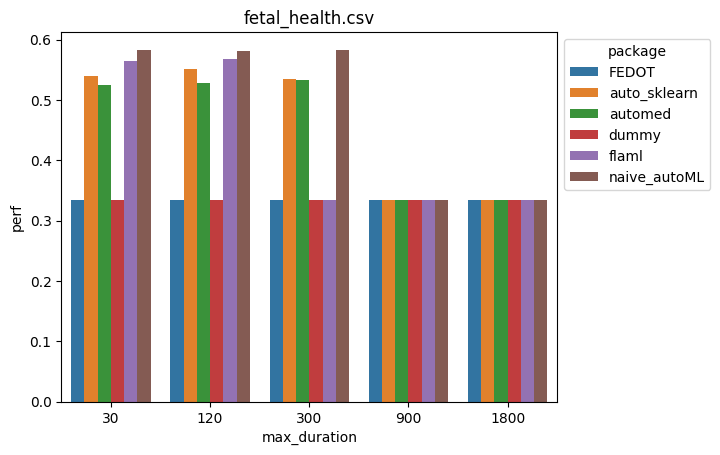

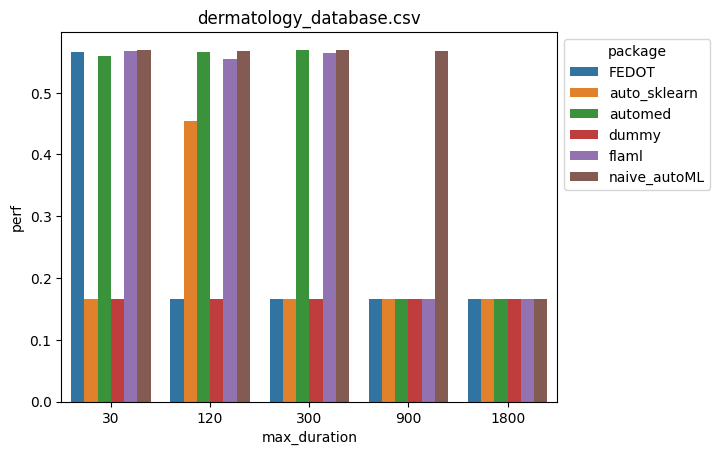

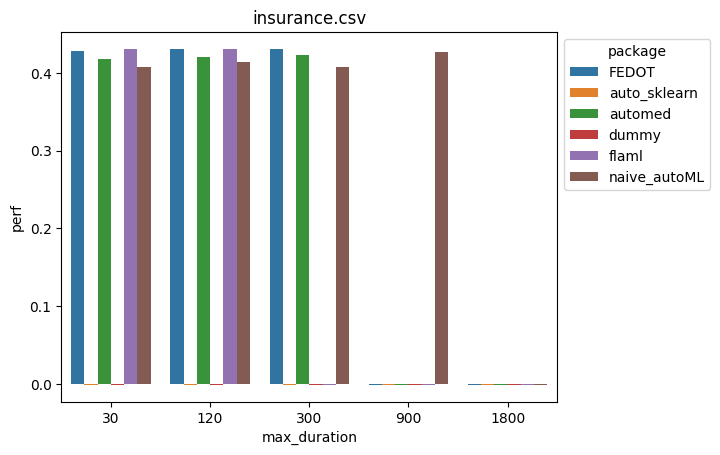

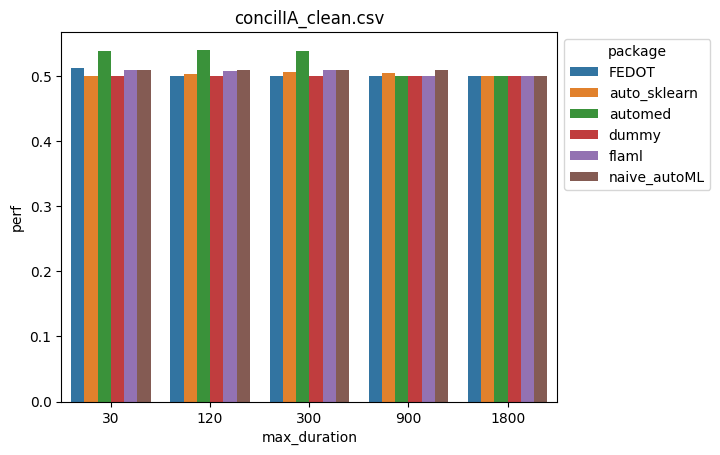

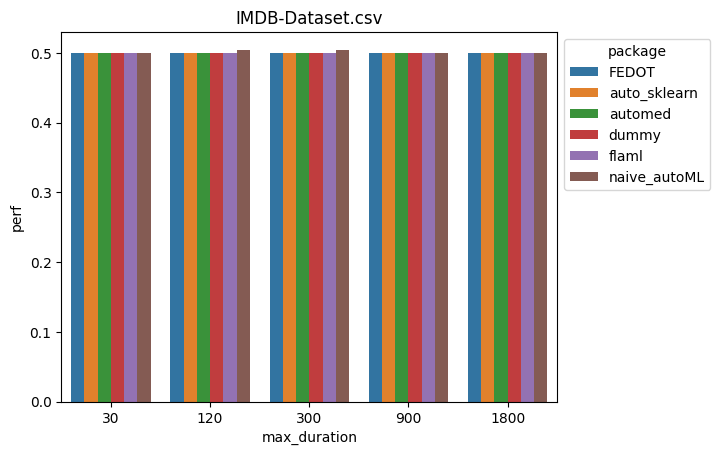

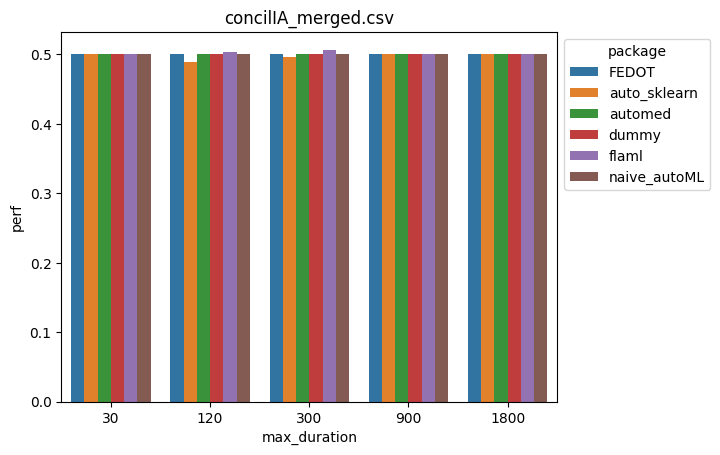

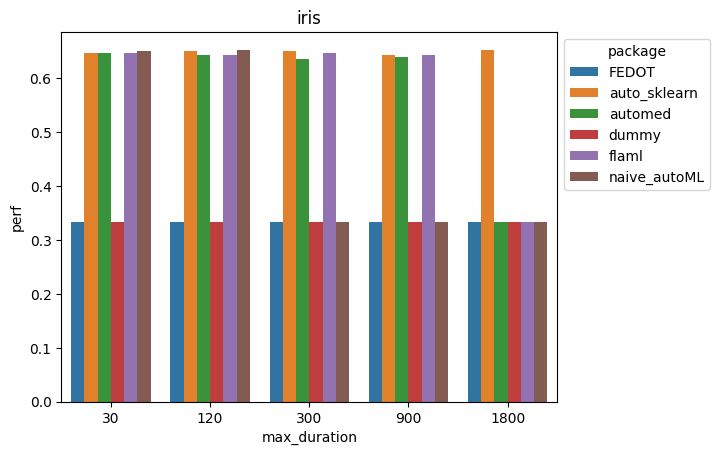

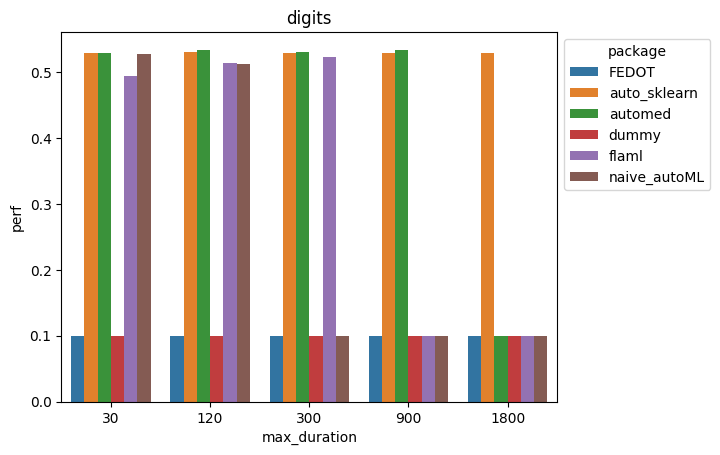

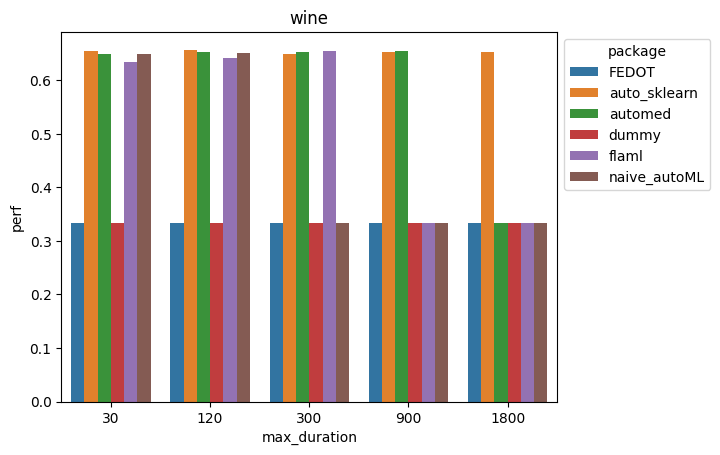

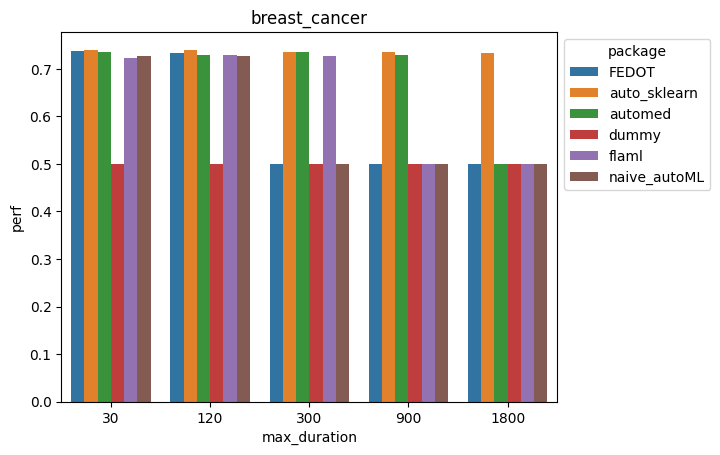

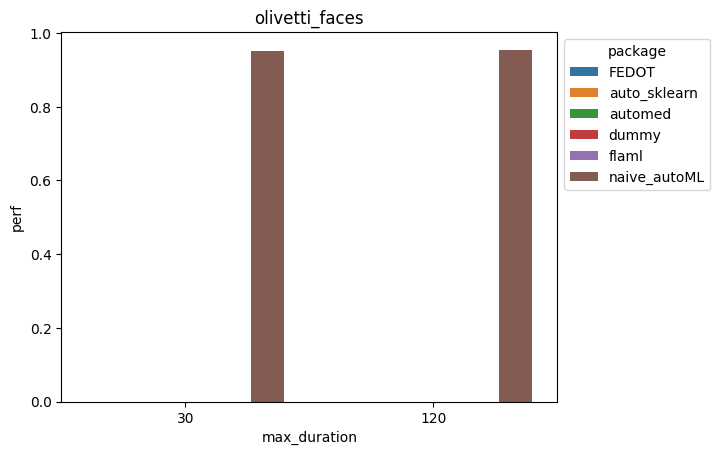

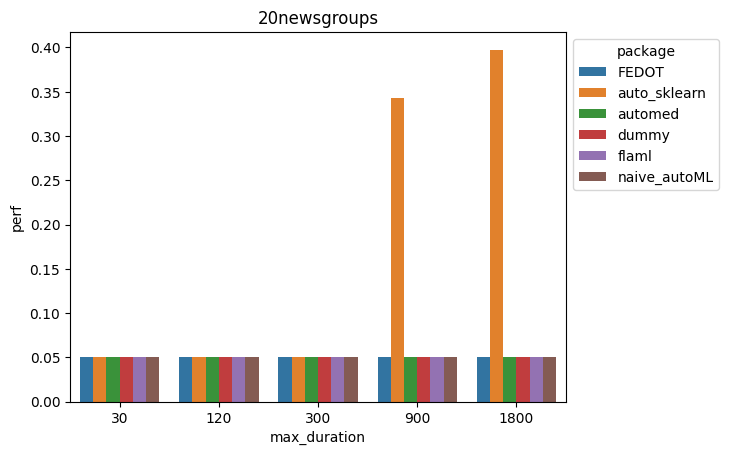

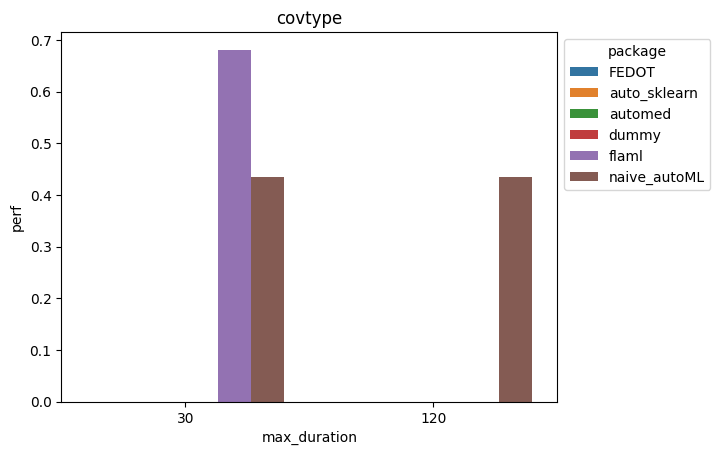

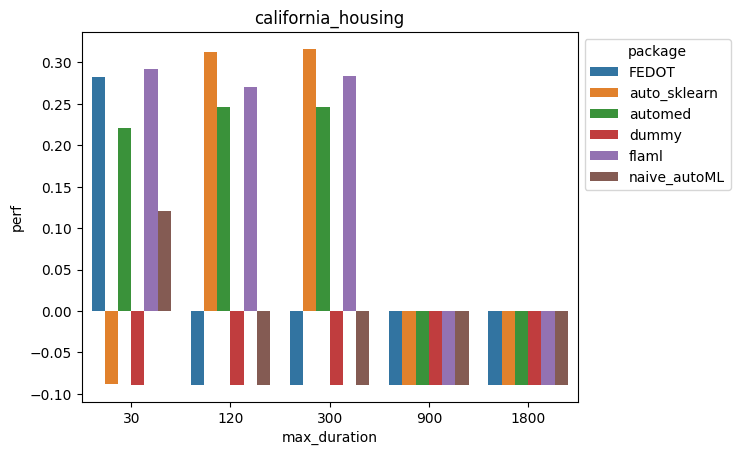

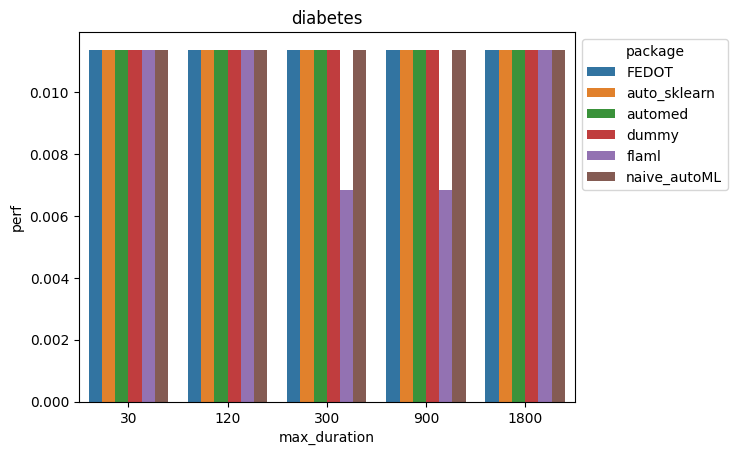

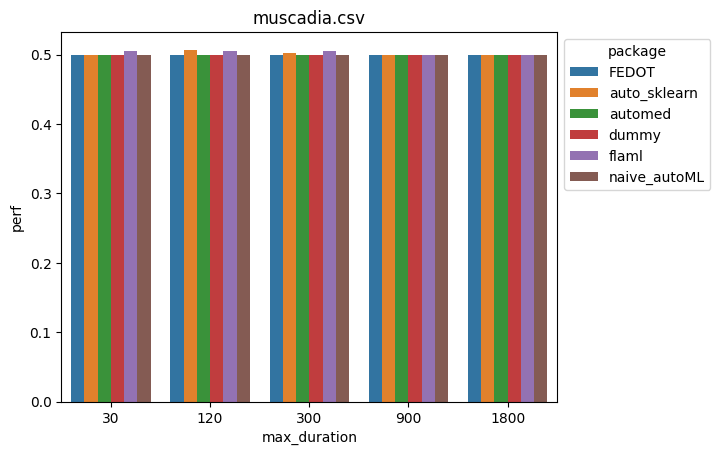

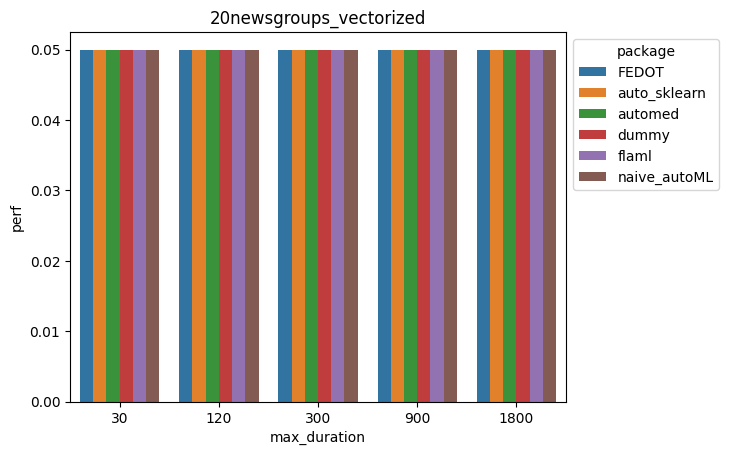

In [14]:
# plt.figure(figsize=(10, 6))
for dataset in merged_df['dataset'].unique():
    bar_plot(bench, dataset)

In [15]:
# line_plot(merged_df, ("package", "AutoMed_void"))

In [16]:
# line_plot(merged_df, ("package", "NaiveAutoML"))

In [17]:
# line_plot(merged_df, ("package", "Auto-Sklearn"))

In [18]:
# for dataset_name in merged_df['dataset_name'].unique():
#     line_plot(merged_df, ("dataset_name", dataset_name), hue="package")

In [19]:
# Diff with automed ?
# Ensure df is a copy to avoid SettingWithCopyWarning
df = merged_df.copy()

# Separate 'automed' and other packages
automed_df = df[df['package'] == 'automed']
other_df = df[df['package'] != 'automed']

# Average 'automed' performance for each 'duration' and 'dataset_name' combination
automed_avg_perf = automed_df.groupby(['max_duration', 'dataset'])['perf'].mean()

# Merge this average performance back into the other_df based on 'max_duration' and 'dataset'
other_df = other_df.merge(automed_avg_perf, on=['max_duration', 'dataset'], suffixes=('', '_automed_avg'))

# Calculate the difference in performance
other_df['perf'] = other_df['perf'] - other_df['perf_automed_avg']

# Drop the now unnecessary 'perf_automed_avg' column
other_df.drop(columns=['perf_automed_avg'], inplace=True)

# Resulting DataFrame has 'automed' rows removed and 'perf' adjusted
df_result = other_df

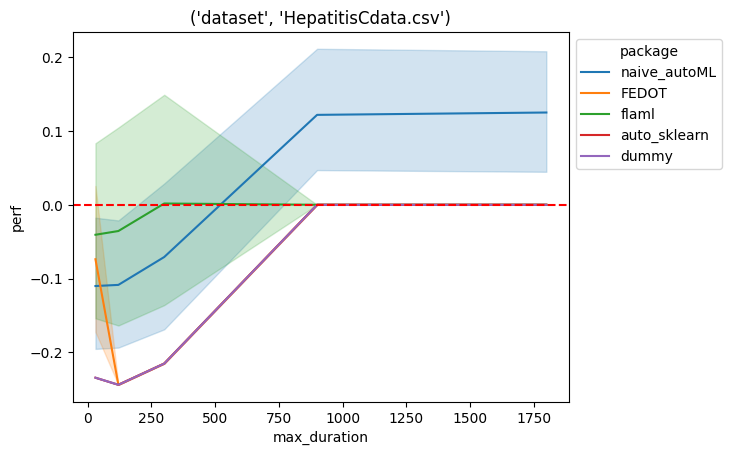

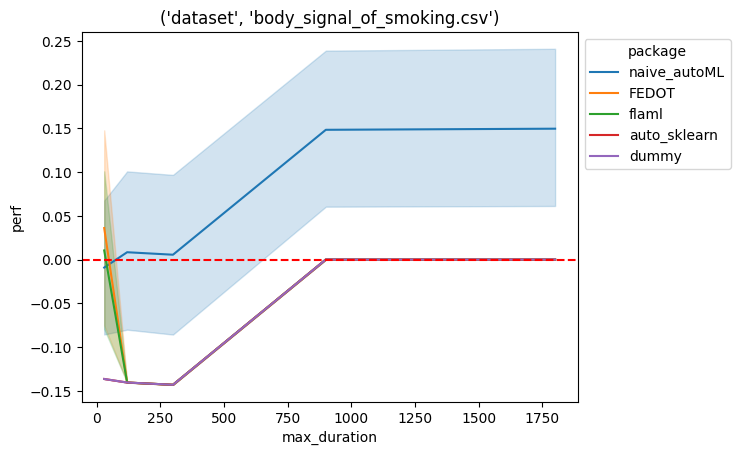

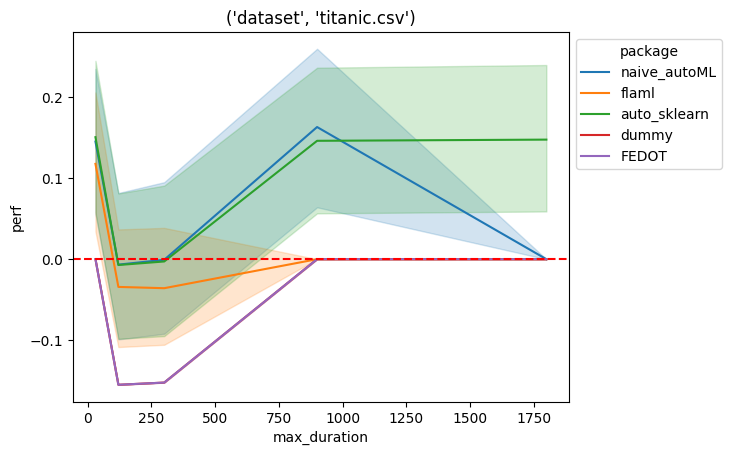

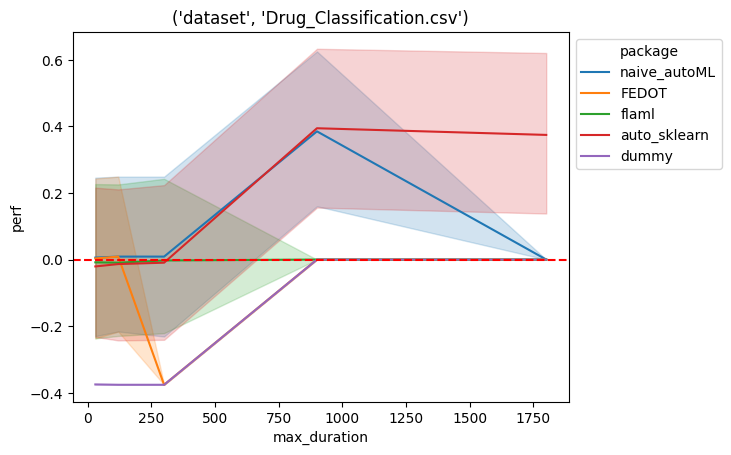

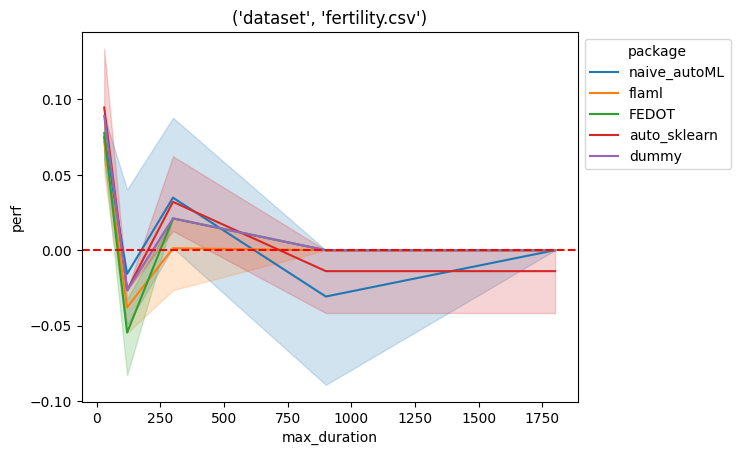

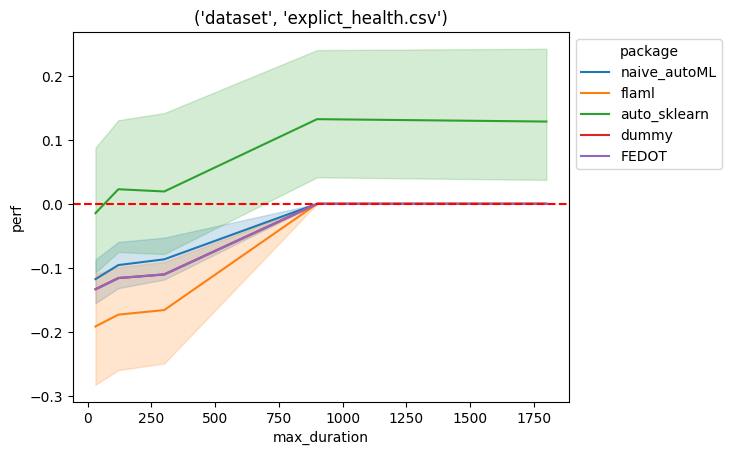

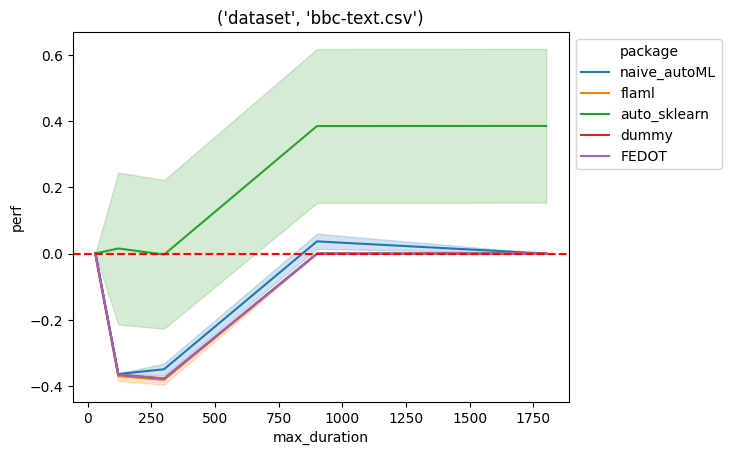

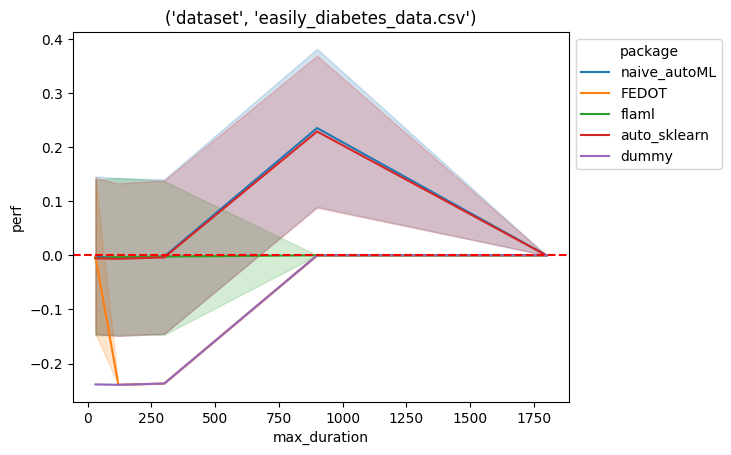

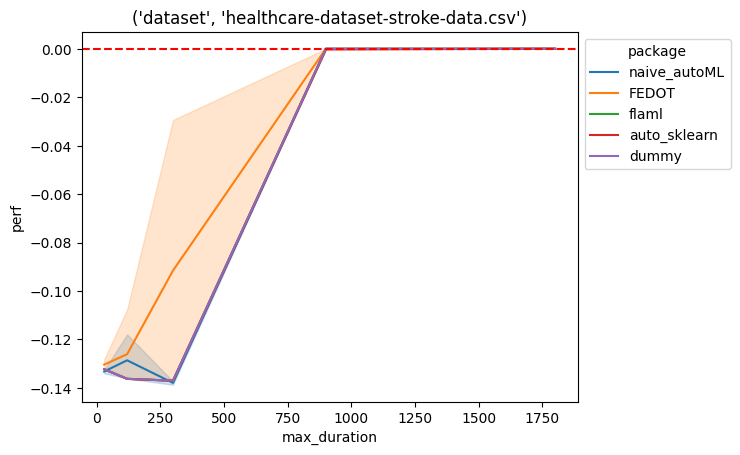

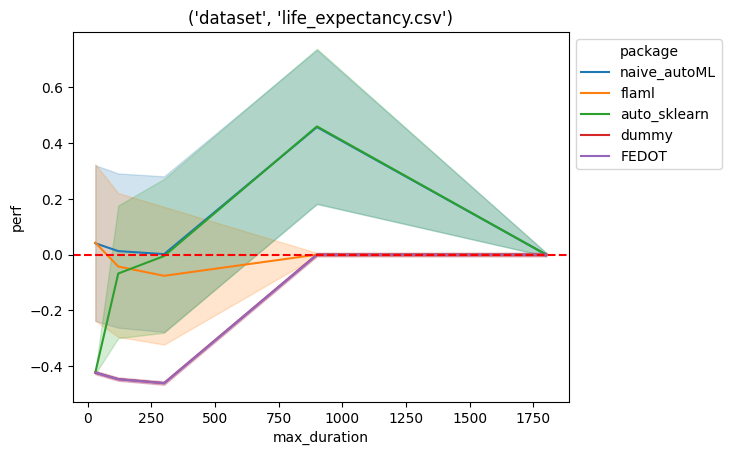

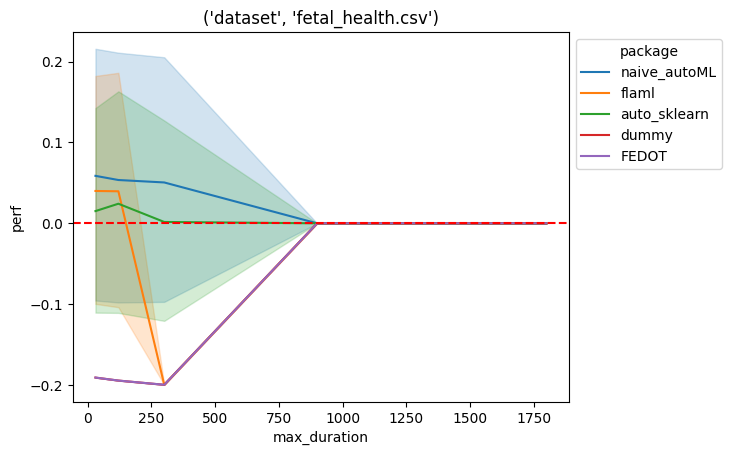

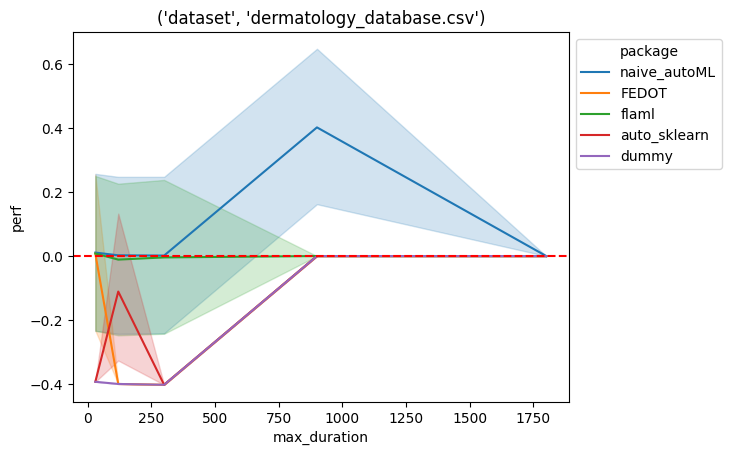

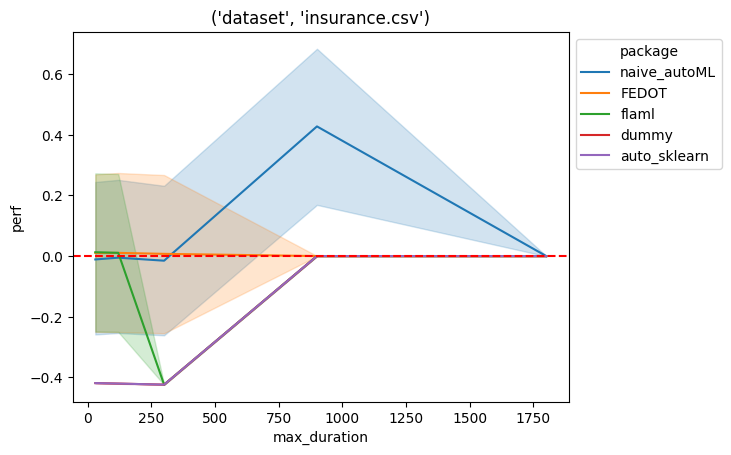

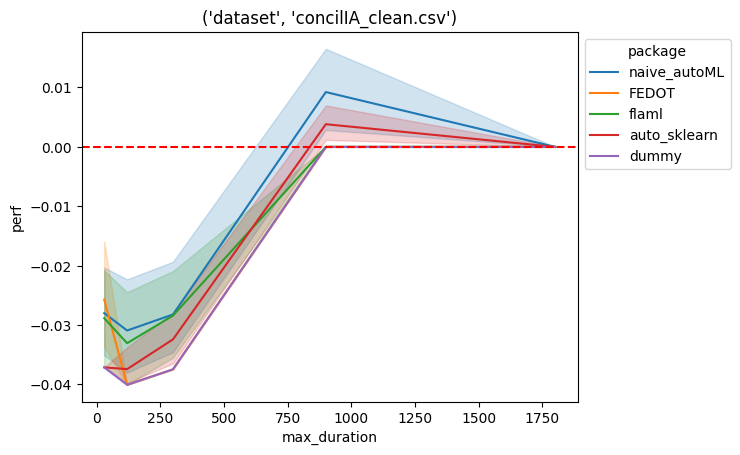

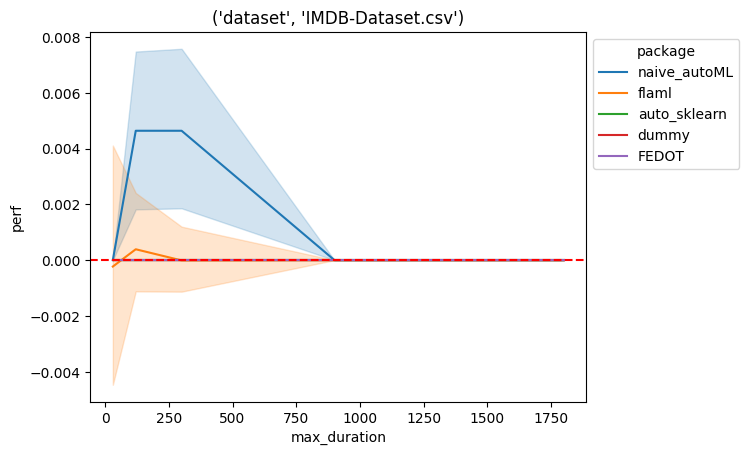

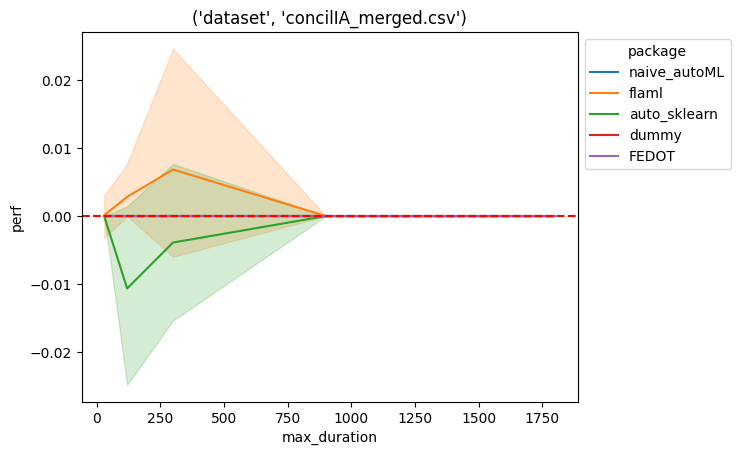

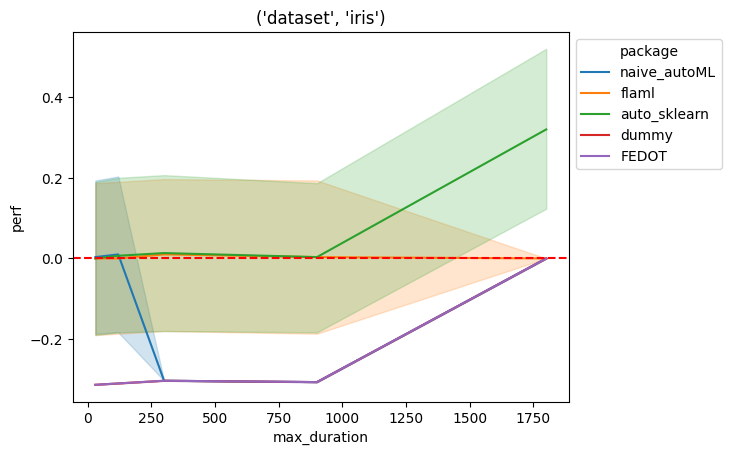

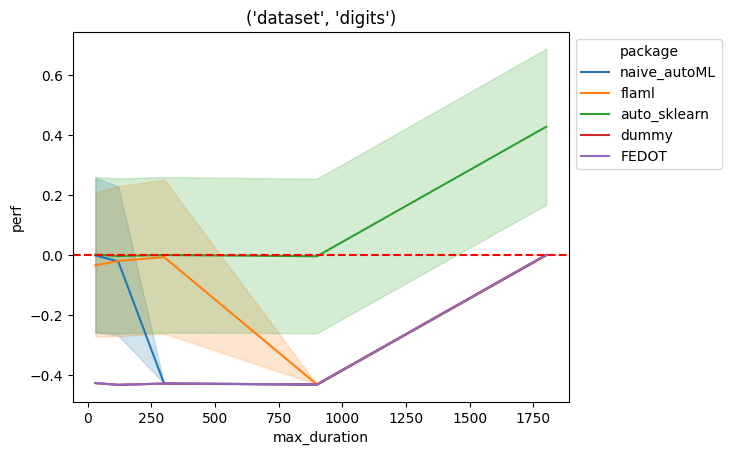

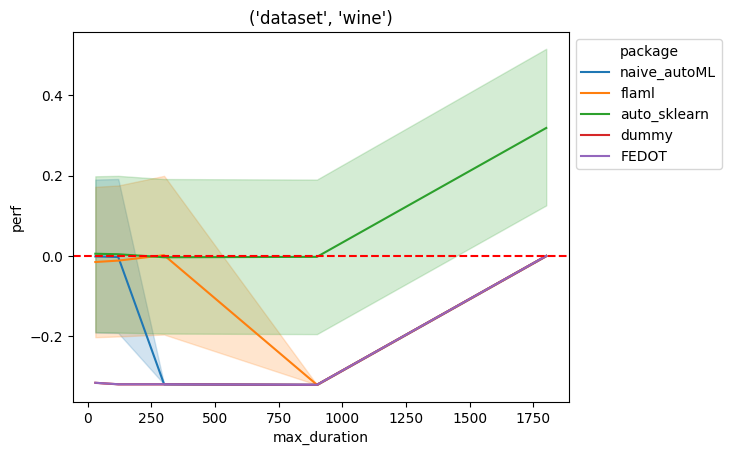

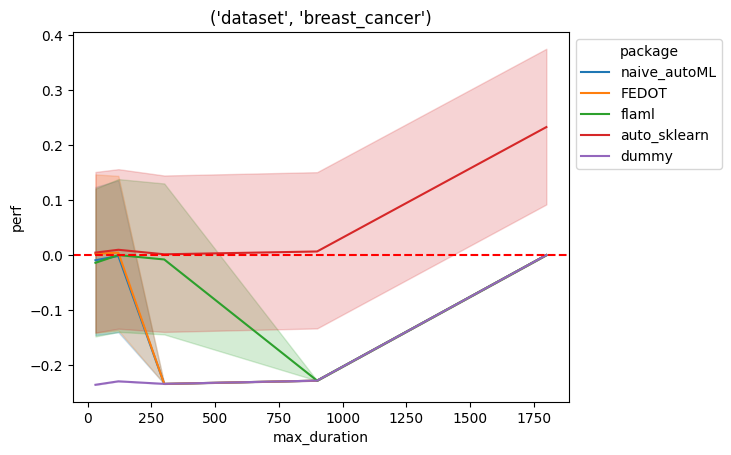

error for olivetti_faces


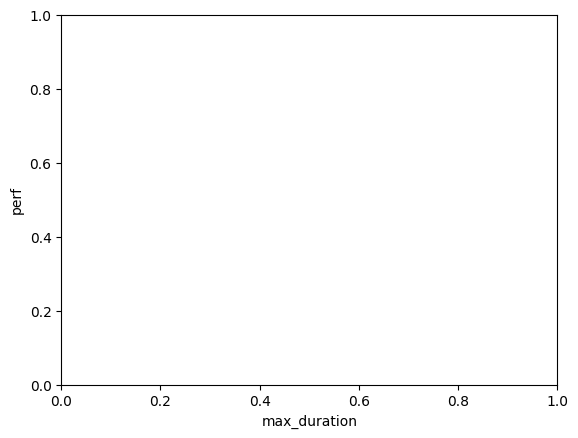

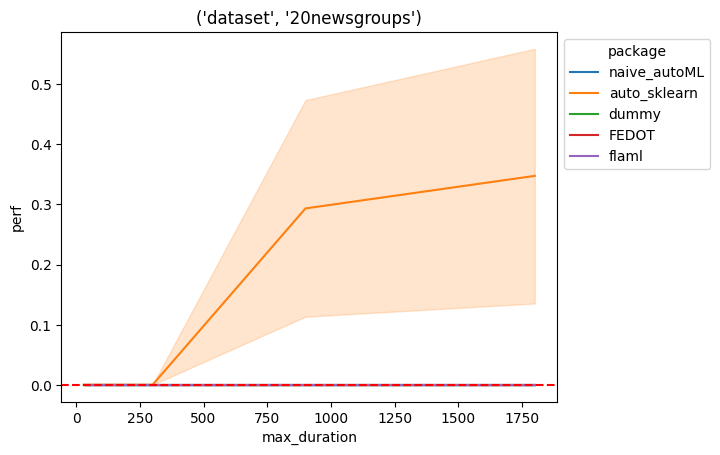

error for covtype


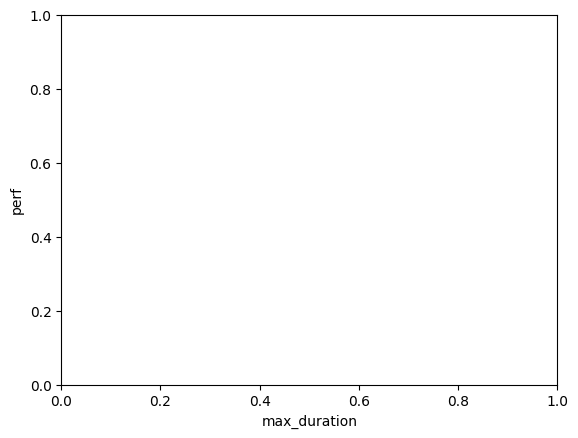

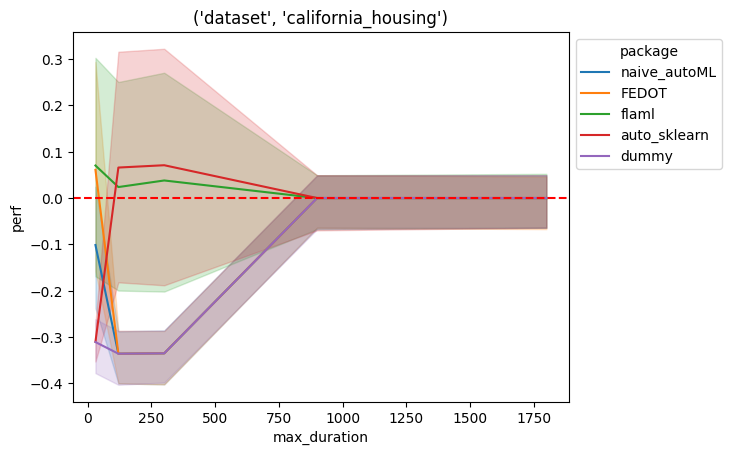

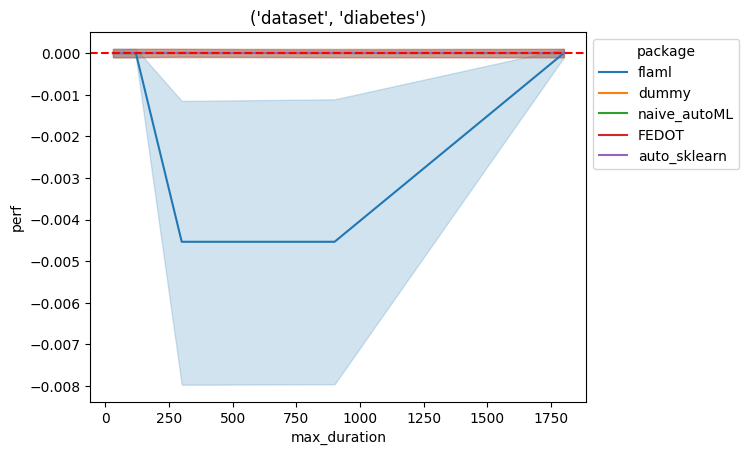

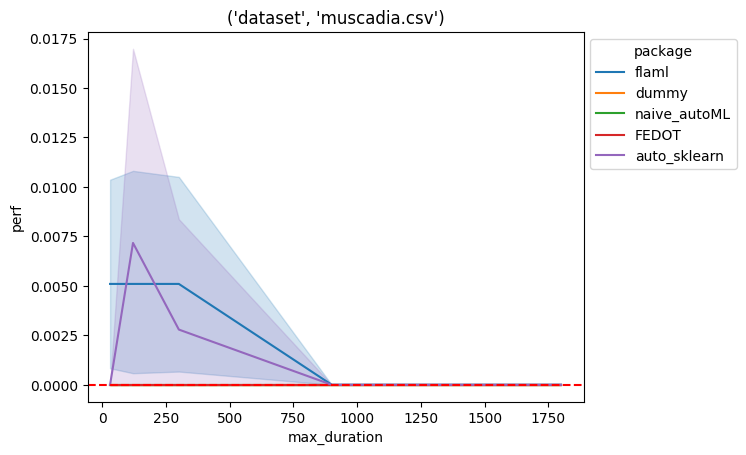

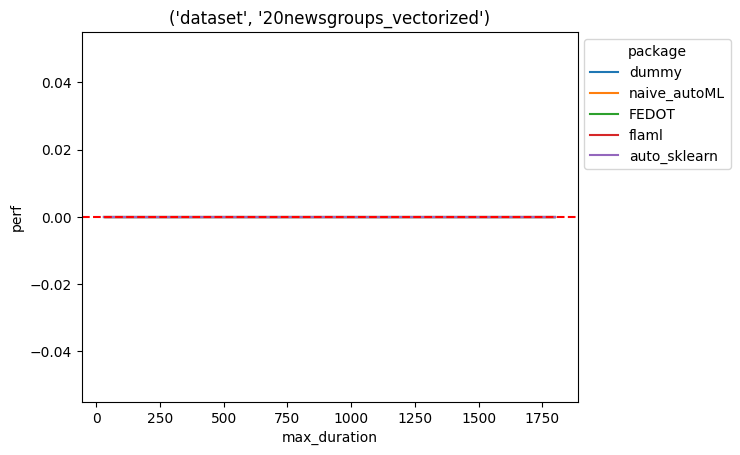

In [20]:
for dataset in merged_df['dataset'].unique():
    try:
        line_plot(df_result, ("dataset", dataset), hue="package", zero_line=True)#, y_lim=(-0.2, 0.2))
    except:
        print(f"error for {dataset}")

# Mean by package and duration

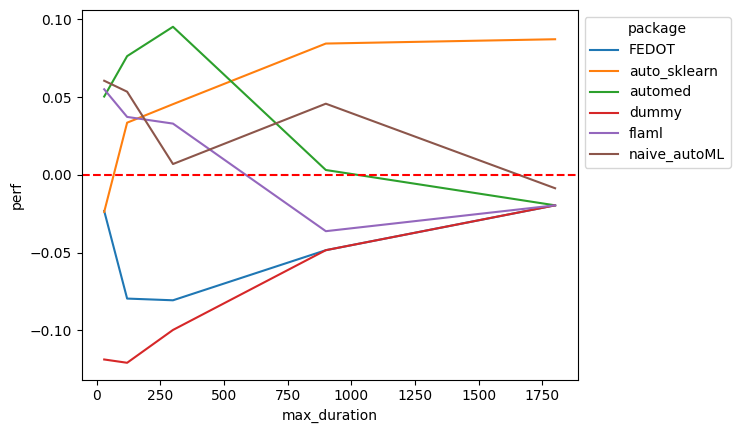

In [21]:
pivot_df = bench.groupby(['package', 'dataset', 'max_duration']).mean(numeric_only=True).reset_index().groupby(['package', 'max_duration']).mean(numeric_only=True).reset_index()

mean_by_package = pivot_df[['package', 'max_duration', 'perf']]
mean_by_duration = mean_by_package.groupby(['max_duration']).mean(numeric_only=True)

joined = mean_by_package.merge(mean_by_duration, on=['max_duration'], suffixes=('', '_by_duration'))
joined['perf'] = joined['perf'] - joined['perf_by_duration']

plt.figure()
plot = sns.lineplot(data=joined, x="max_duration", y="perf", hue="package") 
sns.move_legend(plot, "upper left", bbox_to_anchor=(1, 1))
plt.axhline(y=0.0, color='r', linestyle='--')
plt.show()

# Rank approch

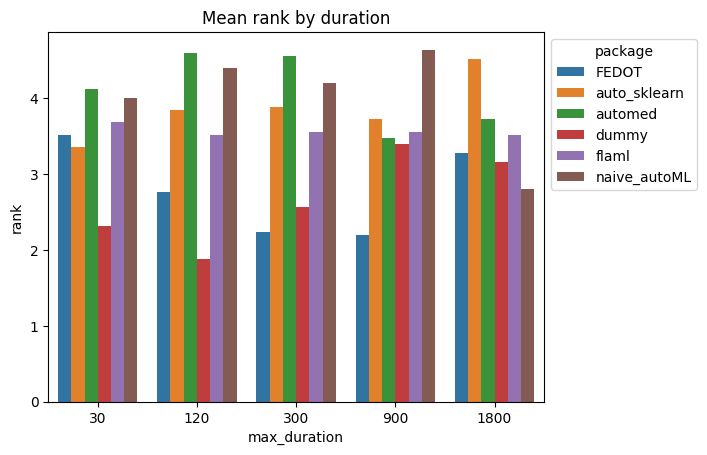

In [22]:
with_rank = bench.copy().groupby(['package', 'max_duration', 'dataset']).mean(numeric_only=True).reset_index()[['max_duration', 'dataset', 'perf', 'package']]

# Remove dataset with nan
with_rank = with_rank.pivot(index=['dataset', 'max_duration'], columns='package').dropna().stack().reset_index()

# Sorting by perf within each group and then ranking
with_rank['rank'] = with_rank.sort_values('perf', ascending=False) \
               .groupby(['max_duration', 'dataset'])['perf'] \
               .rank(method='first', ascending=True)

# Optionally, sort the DataFrame by max_duration, dataset, and rank to see the ranking clearly
with_rank_sorted = with_rank.sort_values(by=['dataset', 'max_duration', 'rank'])

with_rank_sorted = with_rank_sorted[['max_duration', 'dataset', 'rank', 'package']].groupby(['package', 'max_duration']).mean(numeric_only=True)

plot = sns.barplot(data=with_rank_sorted, x='max_duration', y='rank', hue='package')
sns.move_legend(plot, "upper left", bbox_to_anchor=(1, 1))
plt.title('Mean rank by duration')
plt.show()